# Black-box benchmark with quarterly PD and Basel IRB (empirical, FRED)

Empirical counterpart of `03_blackbox_simulated_panel`: the end-to-end black box of the
methodology chapter (S3.2.3), `alpha_bb_{t+1} = g_theta(x_t)`, mapping the macro-financial
features directly to the allocation with **no PD intermediate**, trained on decision
regret (eq. 3.33 / 3.38).

This notebook is scoped to the black box only: it trains and evaluates `blackbox_linear` /
`blackbox_mlp` against the foresight oracle recomputed from realised outcomes (there is no
Bayes oracle for the empirical panel - see `02_pto_empirical`), on the same expanding-window
protocol used everywhere else in this project. It does **not** re-run PTO, does **not**
compute a persistence baseline, and does **not** run Diebold-Mariano tests or any
cross-notebook comparison against PTO or DFL - those live in a separate cross-model
comparison notebook that reads the per-model result CSVs each model notebook saves
(`blackbox_quarterly_pd_irb_predictions_<split>.csv` here, alongside
`pto_quarterly_pd_irb_predictions_<split>.csv` from `02_pto_empirical` and the DFL
equivalent from `04_dfl_empirical`).

Data loading, alignment, the decision environment and evaluation splits (`modern`,
`stress`) are shared with `02_pto_empirical` (`load_quarterly_pd_panel` and the PD/Basel
helper functions are copied verbatim); decision and Basel constants are read from
`empirical_panel_metadata.json`, written by `02_pto_empirical`, and asserted rather than
hardcoded, so the two notebooks cannot silently diverge on the decision environment.

The allocation decision is optimised continuously on `[0, 1]` everywhere - a bounded
scalar solver (`scipy.optimize.minimize_scalar`, Brent's method) for the recomputed
foresight oracle, and the policy network's own sigmoid output used directly with **no
grid snap** anywhere in this notebook.

Empirical specifics of the black-box training signal (vs the simulated notebook):

- the capital requirement in the training loss is `k_irb(pd_a_realised_{t+1})` - the
  realised annualised PD's IRB charge - **matching how the empirical evaluation computes
  realised utility** (in sim it was `K_IRB_true_{t+1}`, matching the sim evaluation);
- the foresight oracle is the only oracle: there is no Bayes oracle and no
  regret decomposition empirically, so `regret` (vs perfect foresight) is the decision
  metric, exactly as in the empirical PTO notebook;
- everything is hindsight-outcome information (realised `c_{t+1}`, its implied IRB
  charge, and the ex-post optimal utility), the same status as PTO training on realised
  `c_{t+1}/LGD`.

Shared with the PTO notebook (fairness rule): features and timing, per-window
`StandardScaler` refit at every test date, the continuous alpha optimiser and utility
constants, evaluation against the foresight oracle, and architecture capacity /
hyperparameter budget (the policy nets reuse the same linear and two-hidden-layer MLP
bodies with a sigmoid head, eq. 3.30-3.31, output read as `alpha`). Different by design:
no prediction stage, no NLL/MSE - the network **is** the decision rule.

In [1]:
from __future__ import annotations

import json
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm
from scipy.optimize import minimize_scalar
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
except ImportError as exc:
    raise ImportError(
        "This notebook needs PyTorch for the linear and MLP PTO models. "
        "Install the project requirements or select the project kernel."
    ) from exc

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "empirical" / "data" / "fred_loan_return_aligned.csv").exists():
    ROOT = ROOT.parent

import sys
sys.path.insert(0, str(ROOT))
from minou_colors import MINOU_COLORS
FIGURES_DIR = ROOT / "empirical" / "figures" / "blackbox"
RESULTS_DIR = ROOT / "empirical" / "results" / "blackbox"
METADATA_PATH = ROOT / "empirical" / "data" / "empirical_panel_metadata.json"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Project root: {ROOT}")
print(f"Figures: {FIGURES_DIR.relative_to(ROOT)}")
print(f"Results: {RESULTS_DIR.relative_to(ROOT)}")

Project root: /Users/hannahokeeffe/Documents/Imperial/DFL_New
Figures: empirical/figures/blackbox
Results: empirical/results/blackbox


## Configuration

Decision and Basel constants (`LGD`, `M`, `K1`, `LEVERAGE`, `Y_BAR`, `LAMBDA`, the PD
floor) are read from `empirical_panel_metadata.json` (written by `02_pto_empirical`) and
asserted against the expected calibration, so this notebook cannot silently diverge from
the PTO notebook. `CHARGE_OFF_CONVERSION = "simple"` inverts FRED's simple x4
annualisation, which is the correct inverse for these series. Allocation decisions are
optimised continuously (`ALPHA_BOUNDS`, `ALPHA_OPT_XATOL`) rather than on a grid.
`BB_SEEDS` / `BB_MODEL_CFG` pin the black box to the same seed-ensemble effort and
capacity/optimiser/early-stopping budget as the PTO MLP in `02_pto_empirical` (fairness
rule), even though PTO itself is not re-run here.

In [2]:
# Data conventions
HORIZON = 1
DATE_COL = "DATE"
TARGET_COL = "charge_off_rate"

# Feature policy: the current-quarter charge-off c_q is realised by decision time
# (start of t+1), modulo a reporting lag. Set False to revert to lag-1 only.
INCLUDE_CURRENT_CQ = True

with open(METADATA_PATH, "r", encoding="utf-8") as f:
    META = json.load(f)
CONST = META["constants"]

# Decision and Basel constants (from 02_pto_empirical's metadata, asserted not assumed)
CHARGE_OFF_IS_PERCENT = bool(CONST["CHARGE_OFF_IS_PERCENT"])
CHARGE_OFF_CONVERSION = str(CONST["CHARGE_OFF_CONVERSION"])
LGD = float(CONST["LGD"])
M = float(CONST["M"])
K1 = float(CONST["K1"])
LEVERAGE = float(CONST["ell"])
Y_BAR = float(CONST["Y_BAR"])
LAMBDA = float(CONST["lambda_shortfall"])
APPLY_PD_FLOOR = bool(CONST["APPLY_PD_FLOOR"])
PD_FLOOR = float(CONST["PD_FLOOR"])
assert LGD == 0.45 and K1 == 1.0 and LEVERAGE == 10.0, "Panel constants differ from expected calibration."
assert bool(CONST["INCLUDE_CURRENT_CQ"]) == INCLUDE_CURRENT_CQ, \
    "INCLUDE_CURRENT_CQ differs from the PTO notebook's panel metadata."

PD_Q_CLIP_LOW = float(CONST["PD_CLIP_LOW"])
PD_Q_CLIP_HIGH = float(CONST["PD_CLIP_HIGH"])
PD_A_CLIP_LOW = 1e-6
PD_A_CLIP_HIGH = 0.99

# Allocation decisions are optimised continuously on [0, 1] with a bounded scalar solver
# rather than snapped to a discrete grid - there is no grid anywhere in this notebook.
ALPHA_BOUNDS = (float(CONST["alpha_bounds_min"]), float(CONST["alpha_bounds_max"]))
ALPHA_OPT_XATOL = float(CONST["alpha_opt_xatol"])

# Evaluation splits: separate expanding-window experiments (same as 02_pto_empirical).
EVAL_SPLITS = {
   # "modern": {"initial_train_frac": 0.75},
    "stress": {"first_test_date": "2006-01-01"},
}

# ---- Black-box specifics ----------------------------------------------------------------
# The black box maps features directly to the allocation alpha and trains on realised
# decision regret. It has no PD stage, so the PTO notebook's LOSS / NLL_* / TARGET_TRANSFORM
# switches do not apply here.
@dataclass
class ModelConfig:
    hidden_dim: int = 16
    lr: float = 1e-3
    weight_decay: float = 1e-4
    batch_size: int = 16
    epochs: int = 500
    patience: int = 75
    val_frac: float = 0.2
    seed: int = 42

# Same ModelConfig field values as 02_pto_empirical's MODEL_CFG (fairness rule): no model
# gets a different training budget.
BB_MODEL_CFG = ModelConfig()
BB_SEEDS = (42, 43, 44, 45, 46)  # same seed-ensemble effort as the PTO MLP

print(f"Constants from metadata: LGD={LGD}, LEVERAGE={LEVERAGE}, Y_BAR={Y_BAR}, LAMBDA={LAMBDA}, "
      f"PD floor={PD_FLOOR} (applied={APPLY_PD_FLOOR})")
print(f"Black box: policy net (linear + MLP, sigmoid head -> alpha), trained on realised "
      f"regret with K = k_irb(pd_a_realised); seeds {BB_SEEDS}; same ModelConfig as PTO.")

Constants from metadata: LGD=0.45, LEVERAGE=10.0, Y_BAR=0.0168, LAMBDA=10.0, PD floor=0.0003 (applied=True)
Black box: policy net (linear + MLP, sigmoid head -> alpha), trained on realised regret with K = k_irb(pd_a_realised); seeds (42, 43, 44, 45, 46); same ModelConfig as PTO.


## Assumptions and caveats

These are held fixed by design; each materially shapes the results and should be restated
wherever results are reported.

- **Constant LGD = 0.45.** Realised PD is backed out as `c_q / LGD`, so "PD" here is a
  rescaled charge-off rate. LGD is procyclical in reality and Basel requires downturn LGD.
- **Corporate IRB curve on an aggregate charge-off series.** The asset-correlation function,
  maturity adjustment, and 0.03% floor are the wholesale/corporate ones. If the underlying
  FRED series is retail/consumer, the retail risk-weight functions (different correlation,
  no maturity adjustment) would apply.
- **Point-in-time PD in a through-the-cycle formula.** Next-quarter PD is annualised as
  `1-(1-pd_q)^4` (independence across quarters) and fed into the IRB formula, making capital
  procyclical; Basel intends TTC PDs.
- **Constant quarterly yield `Y_BAR` and constant leverage** regardless of the rate
  environment.
- **Final-vintage macro data.** Features use revised series, and quarter-t values (e.g. GDP)
  are not published until well into t+1 — a mild look-ahead relative to real-time
  deployment. Including `c_q` as a feature likewise assumes the quarter-t charge-off is
  observable at decision time; set `INCLUDE_CURRENT_CQ = False` to enforce a full
  one-quarter reporting lag.
- **Oracle regret** uses per-period perfect foresight of both `c_q` and the annualised PD
  entering the capital requirement, so regret mixes forecast error with capital-requirement
  foresight.
- **Capital buffer add-on.** Committed capital is excluded from the available buffer;
  equivalently the requirement is `K_IRB + 1/LEVERAGE` per unit exposure, i.e. the
  regulatory minimum plus a fixed management buffer. Calibrated so the constraint binds
  in the interior of the allocation range - without it the constraint never binds for
  alpha in [0,1] and the decision is degenerate at alpha = 1.- **Black-box training signal is hindsight-outcome information only.** Per training
  sample it uses realised `c_q_{t+1}`, the realised annualised PD's IRB charge
  `k_irb(pd_a_realised_{t+1})`, and the foresight-oracle utility - the same information
  status as PTO training on realised `c_{t+1}/LGD`. These enter as training TARGETS only;
  the input features are identical to the PTO models', and constructed PD columns remain
  excluded.
- **The oracle-regret caveat above applies with extra force to the black box**: because
  it trains directly on foresight-oracle regret, its training signal mixes charge-off
  hindsight with capital-requirement hindsight in exactly the way the evaluation does.
  That is by construction (train and test objectives coincide) and is the intended
  contrast with PTO's decision-blind prediction stage.


## Quarterly PD, Basel IRB, and allocation objective

In [3]:
def annual_chargeoff_to_quarterly(c_annual, conversion=CHARGE_OFF_CONVERSION):
    c_annual = np.asarray(c_annual, dtype=float)
    if conversion == "compound":
        return 1.0 - np.power(1.0 - c_annual, 1.0 / 4.0)
    if conversion == "simple":
        return c_annual / 4.0
    raise ValueError("CHARGE_OFF_CONVERSION must be 'compound' or 'simple'.")


def clip_pd_q(pd_q):
    return np.clip(np.asarray(pd_q, dtype=float), PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH)


def clip_pd_a(pd_a):
    return np.clip(np.asarray(pd_a, dtype=float), PD_A_CLIP_LOW, PD_A_CLIP_HIGH)


def quarterly_pd_to_annual(pd_q):
    pd_q = clip_pd_q(pd_q)
    return clip_pd_a(1.0 - np.power(1.0 - pd_q, 4.0))


def k_irb_from_annual_pd(pd_a, lgd=LGD, m=M, apply_floor=APPLY_PD_FLOOR):
    # Basel IRB capital requirement per unit exposure. Input must be annual PD.
    pd_a = clip_pd_a(pd_a)
    if apply_floor:
        pd_a = np.maximum(pd_a, PD_FLOOR)
    exp_term = (1.0 - np.exp(-50.0 * pd_a)) / (1.0 - np.exp(-50.0))
    r = 0.12 * exp_term + 0.24 * (1.0 - exp_term)
    b = np.square(0.11852 - 0.05478 * np.log(pd_a))
    maturity_adj = (1.0 + (m - 2.5) * b) / (1.0 - 1.5 * b)
    z = norm.ppf(pd_a) / np.sqrt(1.0 - r) + np.sqrt(r / (1.0 - r)) * norm.ppf(0.999)
    k_irb = lgd * (norm.cdf(z) - pd_a) * maturity_adj
    return np.maximum(k_irb, 0.0)


def allocation_utility(alpha, c_q, pd_a, leverage=LEVERAGE, y_bar=Y_BAR, lambda_penalty=LAMBDA, k1=K1, lgd=LGD, m=M):
    # U(alpha; c_q, pd_a), with pd_a used only for Basel IRB capital.
    # Buffer semantics (intentional): committed capital alpha*k1 is excluded from the
    # available buffer. Algebraically identical to requiring K_IRB plus a fixed
    # management buffer add-on of 1/LEVERAGE per unit exposure; this is what makes the
    # capital constraint bind in the interior of the alpha domain (without it the
    # constraint never binds on [0,1] and every model would choose alpha = 1).
    alpha = np.asarray(alpha, dtype=float)
    c_q = float(c_q)
    pd_a = float(clip_pd_a(pd_a))
    exposure = leverage * alpha * k1
    terminal_capital = k1 + exposure * (y_bar - c_q)
    committed_capital = alpha * k1
    available_buffer = terminal_capital - committed_capital
    required_capital = k_irb_from_annual_pd(pd_a, lgd=lgd, m=m) * exposure
    shortfall = np.maximum(required_capital - available_buffer, 0.0)
    return terminal_capital - lambda_penalty * shortfall


def decision_components(alpha, c_q, pd_a):
    exposure = LEVERAGE * alpha * K1
    terminal_capital = K1 + exposure * (Y_BAR - c_q)
    committed_capital = alpha * K1
    available_buffer = terminal_capital - committed_capital
    k_irb = float(k_irb_from_annual_pd(pd_a))
    required_capital = k_irb * exposure
    shortfall = max(required_capital - available_buffer, 0.0)
    utility = terminal_capital - LAMBDA * shortfall
    return dict(exposure=exposure, terminal_capital=terminal_capital, committed_capital=committed_capital,
                available_buffer=available_buffer, required_capital=required_capital, shortfall=shortfall,
                utility=utility, k_irb=k_irb)


def optimise_alpha_continuous(c_q, pd_a):
    """Continuous optimum of allocation_utility(alpha; c_q, pd_a) on [0, 1] - used for the
    foresight oracle here (recomputed from realised outcomes; verbatim from
    02_pto_empirical). Brent's method via scipy.optimize.minimize_scalar, bounded on
    ALPHA_BOUNDS with tolerance ALPHA_OPT_XATOL; both domain boundaries are checked
    explicitly."""
    def neg_utility(alpha):
        return -float(allocation_utility(alpha, c_q=c_q, pd_a=pd_a))

    opt = minimize_scalar(neg_utility, bounds=ALPHA_BOUNDS, method="bounded",
                           options={"xatol": ALPHA_OPT_XATOL})
    candidates = [(0.0, -neg_utility(0.0)), (1.0, -neg_utility(1.0)), (float(opt.x), -float(opt.fun))]
    return max(candidates, key=lambda item: item[1])

## Load and align data

The forecasting row is `x_t -> PD_Q_{t+1}`; result columns are named for the realised
next-period outcome, because that is the period used for decision evaluation.

Features now include the current-quarter charge-off `c_q` (realised by decision time,
subject to a reporting lag — see the assumptions cell) alongside `c_q_lag1`. Constructed PD
columns (`pd_q`, `pd_a`) remain excluded: realised PD is built from charge-offs for the
target/evaluation convention, not treated as an observed signal.
After loading, the per-quarter foresight oracle (`alpha_oracle_next`,
`utility_oracle_next`) and the realised IRB charge `k_irb_realised_next` are precomputed
once: they are the black box's training signal and are identical to the quantities
`build_result_row` recomputes per test row.


In [4]:
def load_quarterly_pd_panel(macro_csv, chargeoff_csv, date_col=DATE_COL, target_col=TARGET_COL, feature_cols=None, horizon=HORIZON):
    macro = pd.read_csv(macro_csv)
    charge = pd.read_csv(chargeoff_csv)
    macro[date_col] = pd.to_datetime(macro[date_col]).dt.to_period("Q").dt.start_time
    charge[date_col] = pd.to_datetime(charge[date_col]).dt.to_period("Q").dt.start_time

    if target_col not in charge.columns:
        raise ValueError(f"{target_col!r} not found in charge-off columns: {list(charge.columns)}")

    charge["c_annual_raw"] = pd.to_numeric(charge[target_col], errors="coerce")
    charge["c_annual_decimal"] = charge["c_annual_raw"] / 100.0 if CHARGE_OFF_IS_PERCENT else charge["c_annual_raw"]
    charge["c_q"] = annual_chargeoff_to_quarterly(charge["c_annual_decimal"].to_numpy())
    charge["pd_q"] = clip_pd_q(charge["c_q"].to_numpy() / LGD)
    charge["pd_a"] = quarterly_pd_to_annual(charge["pd_q"].to_numpy())

    keep_charge = [date_col, "c_annual_raw", "c_annual_decimal", "c_q", "pd_q", "pd_a"]
    df = pd.merge(macro, charge[keep_charge], on=date_col, how="inner").sort_values(date_col).reset_index(drop=True)

    # Observed autoregressive signals. PD columns are never features.
    df["c_q_lag1"] = df["c_q"].shift(1)

    df["target_date"] = df[date_col].shift(-horizon)
    df["c_annual_raw_next"] = df["c_annual_raw"].shift(-horizon)
    df["c_q_realised"] = df["c_q"].shift(-horizon)
    df["pd_q_realised"] = df["pd_q"].shift(-horizon)
    df["pd_a_realised"] = df["pd_a"].shift(-horizon)
    df["target_pd_q_next"] = df["pd_q_realised"]

    if feature_cols is None:
        exclude = {date_col, "c_annual_raw", "c_annual_decimal", "pd_q", "pd_a", "target_date",
                   "c_annual_raw_next", "c_q_realised", "pd_q_realised", "pd_a_realised", "target_pd_q_next"}
        if not INCLUDE_CURRENT_CQ:
            exclude.add("c_q")
        feature_cols = [c for c in df.columns if c not in exclude]
    else:
        feature_cols = list(feature_cols)

    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    required = feature_cols + ["c_q", "target_date", "c_annual_raw_next", "c_q_realised", "pd_q_realised", "pd_a_realised", "target_pd_q_next"]
    required = list(dict.fromkeys(required))
    df = df.dropna(subset=required).reset_index(drop=True)
    if len(df) < 30:
        raise ValueError(f"Only {len(df)} usable observations after alignment; check dates and missing values.")
    df.attrs["feature_cols"] = feature_cols
    return df

macro_csv = ROOT / "empirical" / "data" / "macro_panel_quarterly.csv"
chargeoff_csv = ROOT / "empirical" / "data" / "fred_loan_return_aligned.csv"
df = load_quarterly_pd_panel(macro_csv, chargeoff_csv)
feature_cols = df.attrs["feature_cols"]

print(f"Observations after alignment and one-step target: {len(df)}")
print(f"Feature date range: {df[DATE_COL].min().date()} to {df[DATE_COL].max().date()}")
print(f"Target date range: {df['target_date'].min().date()} to {df['target_date'].max().date()}")
print(f"Features ({len(feature_cols)}): {feature_cols}")
assert "c_q_lag1" in feature_cols
assert ("c_q" in feature_cols) == INCLUDE_CURRENT_CQ
assert not any(col.startswith("pd_q") or col.startswith("pd_a") for col in feature_cols)
print(f"Lag features included: c_q_lag1{' and current-quarter c_q' if INCLUDE_CURRENT_CQ else ''}; PD columns excluded.")
display(df.head())

# Foresight-oracle allocation and utility per TARGET quarter (perfect hindsight of
# c_q_{t+1} and pd_a_realised_{t+1}; identical to build_result_row's recomputation).
# Hindsight-outcome information: used only as the black box's training signal, never as
# a feature.
_oracle = [optimise_alpha_continuous(c_q=float(c), pd_a=float(p))
           for c, p in zip(df["c_q_realised"], df["pd_a_realised"])]
df["alpha_oracle_next"] = [a for a, _ in _oracle]
df["utility_oracle_next"] = [u for _, u in _oracle]
# Capital requirement entering the black-box training loss: the realised annualised PD's
# IRB charge, matching how the empirical evaluation computes realised utility.
df["k_irb_realised_next"] = k_irb_from_annual_pd(df["pd_a_realised"].to_numpy())
assert not set(["alpha_oracle_next", "utility_oracle_next", "k_irb_realised_next"]) & set(feature_cols)
print("Precomputed foresight oracle and realised K_IRB for the black-box training signal.")


Observations after alignment and one-step target: 142
Feature date range: 1990-07-01 to 2025-10-01
Target date range: 1990-10-01 to 2026-01-01
Features (14): ['real_gdp_growth', 'unemployment_rate', 'industrial_production', 'real_disposable_personal_income', 'cpi', 'house_price_index', 'federal_funds_rate', 'treasury_10y_2y_spread', 'vix', 'corporate_bond_spread', 'senior_loan_officer_survey', 'excess_bond_premium', 'c_q', 'c_q_lag1']
Lag features included: c_q_lag1 and current-quarter c_q; PD columns excluded.


,DATE,real_gdp_growth,unemployment_rate,industrial_production,real_disposable_personal_income,cpi,house_price_index,federal_funds_rate,treasury_10y_2y_spread,vix,...,c_q,pd_q,pd_a,c_q_lag1,target_date,c_annual_raw_next,c_q_realised,pd_q_realised,pd_a_realised,target_pd_q_next
0,1990-07-01,0.3,5.700000,0.386851,0.014248,1.712502,0.607283,8.160000,0.602540,25.195556,...,0.003200,0.007111,0.028142,0.003575,1990-10-01,1.30,0.003250,0.007222,0.028577,0.007222
1,1990-10-01,-3.6,6.133333,-1.560018,-0.804251,1.683668,-0.390403,7.743333,0.800161,26.113281,...,0.003250,0.007222,0.028577,0.003200,1991-01-01,1.48,0.003700,0.008222,0.032485,0.008222
2,1991-01-01,-1.9,6.600000,-1.932577,0.306683,0.744790,0.833014,6.426667,0.987167,22.515833,...,0.003700,0.008222,0.032485,0.003250,1991-04-01,1.86,0.004650,0.010333,0.040697,0.010333
3,1991-04-01,3.2,6.833333,0.526353,0.748178,0.591864,0.660265,5.863333,1.231406,17.147031,...,0.004650,0.010333,0.040697,0.003700,1991-07-01,1.97,0.004925,0.010944,0.043064,0.010944
4,1991-07-01,2.0,6.866667,1.390822,0.383417,0.759342,0.195457,5.643333,1.428906,16.634219,...,0.004925,0.010944,0.043064,0.004650,1991-10-01,1.83,0.004575,0.010167,0.040051,0.010167


Precomputed foresight oracle and realised K_IRB for the black-box training signal.


## Black-box policy: features -> alpha, trained on realised regret

Objective (thesis eq. 3.33 / 3.38): mean realised regret over the training window,

    L_BB = (1/T) * sum_t [ U_oracle(t+1) - U(alpha_theta(x_t); c_q_{t+1}, k_irb(pd_a_realised_{t+1})) ]

`U_oracle` does not depend on theta, so minimising mean regret is equivalent to maximising
mean realised utility; regret is kept in the loss so training/validation curves read
directly as regret. Implementation notes:

- **Architecture**: `PolicyNet` - linear / two-hidden-layer MLP bodies with a sigmoid
  head (eq. 3.30-3.31), output read as `alpha in [0, 1]`. Same `ModelConfig` field values
  and seed ensemble as the PTO MLP in `02_pto_empirical` (fairness rule), even though PTO
  itself is not re-run here.
- **Kink**: the shortfall `max(., 0)` is piecewise linear; torch subgradients handle it.
- **K in the training signal**: `k_irb(pd_a_realised_{t+1})` - the empirical convention,
  matching how realised utility is evaluated in this notebook. K enters the loss as a
  per-sample constant, not through theta, so no differentiable IRB formula is needed.
- **Early stopping on validation REGRET** (chronological tail split). The output bias is
  initialised at the mean training-window oracle allocation (hindsight-only information).
- **No grid snap anywhere**: the continuous sigmoid output is used directly as the
  decision, on the same continuous domain `[0, 1]` the foresight oracle acts on -
  `regret >= 0` holds because both share the same continuous objective and solver
  tolerance, not because of a shared discrete grid.
- **Harness entry at the ALPHA level**: `pd_q_hat` / `pd_a_hat` / `c_q_hat` / `k_irb_hat`
  are NaN - there is no PD intermediate.

Because it trains across many realised quarters, the black box directly optimises
empirical expected utility without distributional assumptions - the intended contrast
with PTO's decision-blind prediction stage. Caveat for the write-up: with ~35-80 test
windows and short training samples, the empirical setting gives the black box far fewer
regret observations to learn from than the ~1000-quarter simulation; expect noisier
behaviour, especially in the `stress` split (the GFC is out-of-distribution for a
regret-trained policy just as it is for the MLP predictor).


In [5]:
def torch_allocation_utility(alpha, c_q, k):
    """Differentiable counterpart of allocation_utility - same constants and the same
    intentional buffer semantics (committed capital alpha*K1 excluded from the buffer).
    The kinked shortfall max(., 0) is piecewise linear; torch subgradients handle it."""
    exposure = LEVERAGE * alpha * K1
    terminal_capital = K1 + exposure * (Y_BAR - c_q)
    committed_capital = alpha * K1
    available_buffer = terminal_capital - committed_capital
    required_capital = k * exposure
    shortfall = torch.clamp(required_capital - available_buffer, min=0.0)
    return terminal_capital - LAMBDA * shortfall


class PolicyNet(nn.Module):
    # Outputs a raw score; the allocation decision is sigmoid(score), used directly with
    # no grid snap. Same linear / two-hidden-layer MLP bodies as the PTO PD forecaster in
    # 02_pto_empirical (fairness rule: identical architecture, output read as alpha
    # instead of PD).
    def __init__(self, input_dim, model_type, hidden_dim=16):
        super().__init__()
        if model_type == "linear":
            self.net = nn.Linear(input_dim, 1)
        elif model_type == "mlp":
            self.net = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(),
                                     nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1))
        else:
            raise ValueError("model_type must be 'linear' or 'mlp'.")

    def forward(self, x):
        return self.net(x).squeeze(-1)


def init_output_bias_for_alpha(model, alpha_pre_val):
    # Start the policy at the mean training-window oracle allocation (hindsight-outcome
    # info, same status as the regret target itself).
    a_mean = float(np.clip(np.mean(alpha_pre_val), 0.01, 0.99))
    logit_mean = float(np.log(a_mean / (1.0 - a_mean)))
    with torch.no_grad():
        if isinstance(model.net, nn.Linear):
            model.net.bias.fill_(logit_mean)
        else:
            model.net[-1].bias.fill_(logit_mean)


def train_policy_model(x_train, c_next, k_next, u_oracle_next, alpha_oracle_next, model_type,
                       model_cfg, seed=None, return_history=False):
    """Train alpha_theta(x) by minimising mean realised regret
    U_oracle(t+1) - U(alpha_theta(x_t); c_{t+1}, K_{t+1}) over the training window.
    U_oracle is constant in theta, so this equals maximising mean realised utility; it is
    kept in the loss so the train/val curves read directly as regret. Early stopping
    monitors VALIDATION REGRET on the chronological tail."""
    seed = model_cfg.seed if seed is None else int(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)
    n = x_train.shape[0]
    val_size = max(1, int(np.floor(model_cfg.val_frac * n)))
    train_size = n - val_size
    if train_size < 8:
        raise ValueError("Training set too small after validation split.")

    def to_t(a):
        return torch.tensor(np.asarray(a, dtype=float), dtype=torch.float32)

    x_tr, x_val = x_train[:train_size], x_train[train_size:]
    c_tr, c_val = c_next[:train_size], c_next[train_size:]
    k_tr, k_val = k_next[:train_size], k_next[train_size:]
    u_tr, u_val = u_oracle_next[:train_size], u_oracle_next[train_size:]

    train_ds = TensorDataset(to_t(x_tr), to_t(c_tr), to_t(k_tr), to_t(u_tr))
    loader_gen = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=model_cfg.batch_size, shuffle=True, generator=loader_gen)

    model = PolicyNet(input_dim=x_train.shape[1], model_type=model_type, hidden_dim=model_cfg.hidden_dim)
    init_output_bias_for_alpha(model, alpha_oracle_next[:train_size])
    optimiser = torch.optim.AdamW(model.parameters(), lr=model_cfg.lr, weight_decay=model_cfg.weight_decay)

    def regret_loss(score, cb, kb, ub):
        alpha = torch.sigmoid(score)
        return torch.mean(ub - torch_allocation_utility(alpha, cb, kb))

    x_val_t, c_val_t, k_val_t, u_val_t = to_t(x_val), to_t(c_val), to_t(k_val), to_t(u_val)
    best_state, best_val, stale_epochs, history = None, float("inf"), 0, []

    for epoch in range(model_cfg.epochs):
        model.train()
        batch_losses = []
        for xb, cb, kb, ub in train_loader:
            optimiser.zero_grad()
            loss = regret_loss(model(xb), cb, kb, ub)
            loss.backward()
            optimiser.step()
            batch_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            score_val = model(x_val_t)
            val_regret = regret_loss(score_val, c_val_t, k_val_t, u_val_t).item()
            alpha_val = torch.sigmoid(score_val).cpu().numpy()
        history.append({"epoch": epoch + 1, "model": f"blackbox_{model_type}", "seed": seed,
                        "train_loss": float(np.mean(batch_losses)), "val_loss": float(val_regret),
                        "val_mean_alpha": float(np.mean(alpha_val))})

        if val_regret < best_val - 1e-12:
            best_val, stale_epochs = val_regret, 0
            best_state = {kk: v.detach().clone() for kk, v in model.state_dict().items()}
        else:
            stale_epochs += 1
        if stale_epochs >= model_cfg.patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return (model, pd.DataFrame(history)) if return_history else model


def predict_alpha(model, x):
    # Continuous policy output in [0, 1], used directly - no grid snap anywhere.
    model.eval()
    with torch.no_grad():
        alpha = torch.sigmoid(model(torch.tensor(x, dtype=torch.float32))).cpu().numpy()
    return np.clip(np.atleast_1d(alpha), 0.0, 1.0)


def train_policy_ensemble(x_train, c_next, k_next, u_oracle_next, alpha_oracle_next, model_cfg,
                          seeds=BB_SEEDS, return_history=False):
    models, first_hist = [], None
    for i, s in enumerate(seeds):
        want_hist = return_history and i == 0
        out = train_policy_model(x_train, c_next, k_next, u_oracle_next, alpha_oracle_next, "mlp",
                                 model_cfg, seed=s, return_history=want_hist)
        if want_hist:
            model, first_hist = out
        else:
            model = out
        models.append(model)
    return models, first_hist


def predict_alpha_ensemble(models, x):
    preds = np.stack([predict_alpha(m, x) for m in models], axis=0)
    return preds.mean(axis=0), preds.std(axis=0)


## Expanding-window evaluation

At each test date the scaler and the black-box policy net are refit on observations
strictly before the feature date: `blackbox_linear` (single seed) and `blackbox_mlp`
(seed ensemble, continuous alphas averaged - no grid snap anywhere). It enters result
collection through `build_result_row_alpha`: PD fields NaN, everything regret-side as
normal.

Two splits run as separate experiments: `modern` (last 25% of the sample) and `stress`
(test targets from 2006Q1, so the GFC is out-of-sample). The modern test window is
contained in the stress one; they are not independent samples.

In [6]:
def build_result_row_alpha(base_row, alpha_hat_raw, model_name, split_name, alpha_hat_std=float("nan")):
    """Enters the harness at the ALPHA level: there is no PD intermediate, so
    pd_q_hat / pd_a_hat / c_q_hat / k_irb_hat and the predicted-shortfall column are NaN;
    regret and the shortfall bind share apply unchanged. The continuous policy output is
    used directly - no grid snap anywhere."""
    alpha_hat = float(np.clip(alpha_hat_raw, ALPHA_BOUNDS[0], ALPHA_BOUNDS[1]))
    c_q_realised = float(base_row["c_q_realised"])
    pd_q_realised = float(base_row["pd_q_realised"])
    pd_a_realised = float(base_row["pd_a_realised"])
    alpha_oracle, utility_oracle = optimise_alpha_continuous(c_q=c_q_realised, pd_a=pd_a_realised)
    realised_components = decision_components(alpha_hat, c_q=c_q_realised, pd_a=pd_a_realised)
    oracle_components = decision_components(alpha_oracle, c_q=c_q_realised, pd_a=pd_a_realised)
    regret = utility_oracle - realised_components["utility"]
    nan = float("nan")
    return {"split": split_name, "model": model_name, "date": pd.to_datetime(base_row["target_date"]),
            "feature_date": pd.to_datetime(base_row[DATE_COL]), "c_annual_raw": float(base_row["c_annual_raw_next"]),
            "c_q_lag1": float(base_row["c_q_lag1"]),
            "c_q_realised": c_q_realised, "pd_q_realised": pd_q_realised, "pd_a_realised": pd_a_realised,
            "pd_q_hat": nan, "pd_q_hat_std": nan, "pd_a_hat": nan, "c_q_hat": nan,
            "k_irb_realised": float(k_irb_from_annual_pd(pd_a_realised)), "k_irb_hat": nan,
            "alpha_oracle": alpha_oracle, "alpha_hat": alpha_hat,
            "alpha_hat_raw_bb": float(alpha_hat_raw), "alpha_hat_std_bb": float(alpha_hat_std),
            "utility_oracle": utility_oracle,
            "utility": realised_components["utility"], "regret": regret,
            "shortfall_oracle": oracle_components["shortfall"],
            "shortfall_realised_at_hat": realised_components["shortfall"],
            "shortfall_predicted_at_hat": nan}


def resolve_first_test_idx(df, split_cfg):
    if "initial_train_frac" in split_cfg:
        first_test_idx = int(np.floor(len(df) * float(split_cfg["initial_train_frac"])))
    elif "first_test_date" in split_cfg:
        mask = (df["target_date"] >= pd.Timestamp(split_cfg["first_test_date"])).to_numpy()
        if not mask.any():
            raise ValueError("first_test_date is after the last available target date.")
        first_test_idx = int(np.flatnonzero(mask)[0])
    else:
        raise ValueError("Split config needs 'initial_train_frac' or 'first_test_date'.")
    if first_test_idx < 30 or len(df) - first_test_idx < 5:
        raise ValueError(f"Split leaves too little data: first_test_idx={first_test_idx} of {len(df)}.")
    return first_test_idx


def run_expanding_window_pd_irb(df, feature_cols, split_name, split_cfg, model_cfg=BB_MODEL_CFG, return_history=True):
    first_test_idx = resolve_first_test_idx(df, split_cfg)
    total = len(df) - first_test_idx
    print(f"[{split_name}] first test target: {pd.Timestamp(df['target_date'].iloc[first_test_idx]).date()}, "
          f"{total} windows, {first_test_idx} initial training obs")
    records, histories = [], []
    t0 = time.time()
    for test_idx in range(first_test_idx, len(df)):
        train_df = df.iloc[:test_idx]
        test_row = df.iloc[test_idx]
        scaler = StandardScaler()
        x_train = scaler.fit_transform(train_df[feature_cols].to_numpy(dtype=float))
        x_test = scaler.transform(test_row[feature_cols].to_numpy(dtype=float).reshape(1, -1))

        # Black box: same window and scaler; targets are hindsight outcomes
        # (realised c_{t+1}, k_irb(pd_a_realised_{t+1}), foresight-oracle utility).
        c_next_tr = train_df["c_q_realised"].to_numpy(dtype=float)
        k_next_tr = train_df["k_irb_realised_next"].to_numpy(dtype=float)
        u_oracle_tr = train_df["utility_oracle_next"].to_numpy(dtype=float)
        alpha_oracle_tr = train_df["alpha_oracle_next"].to_numpy(dtype=float)
        bb_linear_model, bb_linear_hist = train_policy_model(
            x_train, c_next_tr, k_next_tr, u_oracle_tr, alpha_oracle_tr, "linear",
            model_cfg, return_history=True)
        records.append(build_result_row_alpha(test_row, float(predict_alpha(bb_linear_model, x_test)[0]),
                                              "blackbox_linear", split_name))
        bb_mlp_models, bb_mlp_hist = train_policy_ensemble(
            x_train, c_next_tr, k_next_tr, u_oracle_tr, alpha_oracle_tr, model_cfg,
            return_history=True)
        bb_mean, bb_std = predict_alpha_ensemble(bb_mlp_models, x_test)
        records.append(build_result_row_alpha(test_row, float(bb_mean[0]), "blackbox_mlp", split_name,
                                              alpha_hat_std=float(bb_std[0])))

        if return_history:
            for hist in (bb_linear_hist, bb_mlp_hist):
                if hist is not None:
                    hist = hist.copy()
                    hist["split"] = split_name
                    hist["test_date"] = pd.to_datetime(test_row["target_date"])
                    hist["train_end_date"] = pd.to_datetime(train_df[DATE_COL].iloc[-1])
                    histories.append(hist)

        done = test_idx - first_test_idx + 1
        if done % 5 == 0 or test_idx == len(df) - 1:
            print(f"[{split_name}] completed {done}/{total} windows ({time.time() - t0:.0f}s elapsed)")
    pred_long = pd.DataFrame(records).sort_values(["date", "model"]).reset_index(drop=True)
    history = pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
    return pred_long, history


split_frames, split_histories = [], []
for split_name, split_cfg in EVAL_SPLITS.items():
    pl, th = run_expanding_window_pd_irb(df, feature_cols, split_name, split_cfg)
    split_frames.append(pl)
    split_histories.append(th)
pred_long = pd.concat(split_frames, ignore_index=True)
training_history = pd.concat([h for h in split_histories if not h.empty], ignore_index=True)
display(pred_long.head())

[stress] first test target: 2006-01-01, 81 windows, 61 initial training obs
[stress] completed 5/81 windows (25s elapsed)
[stress] completed 10/81 windows (38s elapsed)
[stress] completed 15/81 windows (48s elapsed)
[stress] completed 20/81 windows (56s elapsed)
[stress] completed 25/81 windows (66s elapsed)
[stress] completed 30/81 windows (76s elapsed)
[stress] completed 35/81 windows (91s elapsed)
[stress] completed 40/81 windows (115s elapsed)
[stress] completed 45/81 windows (142s elapsed)
[stress] completed 50/81 windows (164s elapsed)
[stress] completed 55/81 windows (187s elapsed)
[stress] completed 60/81 windows (208s elapsed)
[stress] completed 65/81 windows (222s elapsed)
[stress] completed 70/81 windows (234s elapsed)
[stress] completed 75/81 windows (244s elapsed)
[stress] completed 80/81 windows (253s elapsed)
[stress] completed 81/81 windows (254s elapsed)


,split,model,date,feature_date,c_annual_raw,c_q_lag1,c_q_realised,pd_q_realised,pd_a_realised,pd_q_hat,...,alpha_oracle,alpha_hat,alpha_hat_raw_bb,alpha_hat_std_bb,utility_oracle,utility,regret,shortfall_oracle,shortfall_realised_at_hat,shortfall_predicted_at_hat
0,stress,blackbox_linear,2006-01-01,2005-10-01,0.21,0.000525,0.000525,0.001167,0.004659,NaN,...,0.726543,0.645933,0.645933,NaN,1.118245,1.105126,0.013119,0.0,0.0,NaN
1,stress,blackbox_mlp,2006-01-01,2005-10-01,0.21,0.000525,0.000525,0.001167,0.004659,NaN,...,0.726543,0.633967,0.633967,0.032979,1.118245,1.103178,0.015067,0.0,0.0,NaN
2,stress,blackbox_linear,2006-04-01,2006-01-01,0.27,0.000775,0.000675,0.001500,0.005987,NaN,...,0.693570,0.643666,0.643666,NaN,1.111838,1.103791,0.008047,0.0,0.0,NaN
3,stress,blackbox_mlp,2006-04-01,2006-01-01,0.27,0.000775,0.000675,0.001500,0.005987,NaN,...,0.693570,0.656637,0.656637,0.011823,1.111838,1.105883,0.005955,0.0,0.0,NaN
4,stress,blackbox_linear,2006-07-01,2006-04-01,0.30,0.000525,0.000750,0.001667,0.006650,NaN,...,0.680266,0.576282,0.576282,NaN,1.109183,1.092493,0.016689,0.0,0.0,NaN


## Result collection

One wide, thesis-facing frame per split covering `blackbox_linear` and `blackbox_mlp` -
the two models this notebook trains. Saved to
`blackbox_quarterly_pd_irb_predictions_<split>.csv`, the file the separate cross-model
comparison notebook reads alongside the equivalent PTO and DFL CSVs.

In [9]:
base_cols = ["date", "c_annual_raw", "c_q_lag1", "c_q_realised", "pd_q_realised", "pd_a_realised",
             "k_irb_realised", "alpha_oracle", "utility_oracle"]
metric_cols = ["alpha_hat", "alpha_hat_std_bb", "utility", "regret"]
MODEL_ORDER = ["blackbox_linear", "blackbox_mlp"]

def make_wide_results(pred_long, split_name):
    sub = pred_long[pred_long["split"] == split_name]
    wide = sub.pivot(index="date", columns="model", values=metric_cols).sort_index()
    wide.columns = [f"{metric}_{model}" for metric, model in wide.columns]
    wide = wide.reset_index()
    base = sub[sub["model"] == "blackbox_linear"][base_cols].copy()
    out = base.merge(wide, on="date", how="left")
    ordered = base_cols + [f"{m}_{mod}" for m in metric_cols for mod in MODEL_ORDER]
    return out[ordered].sort_values("date").reset_index(drop=True)

results_by_split = {}
for split_name in EVAL_SPLITS:
    res = make_wide_results(pred_long, split_name)
    results_by_split[split_name] = res
    output_csv = RESULTS_DIR / f"blackbox_quarterly_pd_irb_predictions_{split_name}.csv"
    res.to_csv(output_csv, index=False)
    print(f"[{split_name}] saved {len(res)} rows to {output_csv.relative_to(ROOT)}")
display(results_by_split["stress"].head())

[stress] saved 81 rows to empirical/results/blackbox/blackbox_quarterly_pd_irb_predictions_stress.csv


,date,c_annual_raw,c_q_lag1,c_q_realised,pd_q_realised,pd_a_realised,k_irb_realised,alpha_oracle,utility_oracle,alpha_hat_blackbox_linear,alpha_hat_blackbox_mlp,alpha_hat_std_bb_blackbox_linear,alpha_hat_std_bb_blackbox_mlp,utility_blackbox_linear,utility_blackbox_mlp,regret_blackbox_linear,regret_blackbox_mlp
0,2006-01-01,0.21,0.000525,0.000525,0.001167,0.004659,0.053913,0.726543,1.118245,0.645933,0.633967,NaN,0.032979,1.105126,1.103178,0.013119,0.015067
1,2006-04-01,0.27,0.000775,0.000675,0.001500,0.005987,0.060307,0.693570,1.111838,0.643666,0.656637,NaN,0.011823,1.103791,1.105883,0.008047,0.005955
2,2006-07-01,0.30,0.000525,0.000750,0.001667,0.006650,0.063051,0.680266,1.109183,0.576282,0.638904,NaN,0.024462,1.092493,1.102544,0.016689,0.006639
3,2006-10-01,0.34,0.000675,0.000850,0.001889,0.007534,0.066343,0.664926,1.106056,0.456640,0.631884,NaN,0.028657,1.072834,1.100786,0.033222,0.005270
4,2007-01-01,0.37,0.000750,0.000925,0.002056,0.008197,0.068577,0.654869,1.103960,0.539300,0.622550,NaN,0.016443,1.085614,1.098830,0.018347,0.005131


## Regret summary and sanity checks

This is a load/alignment sanity check, not a model comparison: the foresight oracle
recomputed here from realised outcomes is checked against the oracle precomputed for the
black-box training signal (same constants, same continuous optimum, so they must agree
exactly). Cross-model statistical comparison (Diebold-Mariano etc. against PTO and DFL)
happens in the separate comparison notebook that reads this notebook's saved CSV
alongside the others - there is no PD to score here (no PD intermediate), so `regret`
and the shortfall bind share are the only decision metrics.

In [10]:
def regret_summary_table(sub):
    rows = []
    for model_name, g in sub.groupby("model"):
        rows.append({"model": model_name, "n": int(len(g)),
                     "mean_regret": float(g["regret"].mean()),
                     "median_regret": float(g["regret"].median()),
                     "mean_utility": float(g["utility"].mean()),
                     "shortfall_bind_share": float((g["shortfall_realised_at_hat"] > 1e-12).mean())})
    return pd.DataFrame(rows).set_index("model").loc[MODEL_ORDER]

for split_name in EVAL_SPLITS:
    sub = pred_long[pred_long["split"] == split_name]
    print(f"=== {split_name} split ===")
    metrics = regret_summary_table(sub)
    display(metrics)
    metrics.to_csv(RESULTS_DIR / f"blackbox_quarterly_pd_irb_metrics_{split_name}.csv")

=== stress split ===


,n,mean_regret,median_regret,mean_utility,shortfall_bind_share
model,,,,,
blackbox_linear,81,0.145854,0.008852,0.953704,0.172840
blackbox_mlp,81,0.013868,0.009056,1.085690,0.037037


## Diagnostics and sanity checks

Alphas must lie in `[0, 1]` (no grid to snap to); the precomputed training-time oracle
(`alpha_oracle_next`/`utility_oracle_next`, used as the black box's training signal) must
agree with the foresight oracle recomputed at evaluation time in `build_result_row_alpha`
(both call `optimise_alpha_continuous` on the same realised `(c_q, pd_a)`, so they should
match to solver tolerance); regret must be `>= 0` for every model.

In [11]:
def describe_columns(frame, cols):
    return frame[cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

print(f"Charge-off conversion: {CHARGE_OFF_CONVERSION!r}; percent input: {CHARGE_OFF_IS_PERCENT}; "
      f"PD floor applied: {APPLY_PD_FLOOR} ({PD_FLOOR:.2%}); BB seeds: {BB_SEEDS}")
print("Black box: trained on realised regret with K = k_irb(pd_a_realised); no PD stage; "
      "continuous alpha output, no grid snap anywhere.")

# --- Shared realised-outcome checks (all rows) ---
assert np.allclose(pred_long["pd_q_realised"], clip_pd_q(pred_long["c_q_realised"] / LGD))
assert np.allclose(pred_long["pd_a_realised"], quarterly_pd_to_annual(pred_long["pd_q_realised"]), atol=1e-12)
for col in ["pd_q_realised", "pd_a_realised"]:
    vals = pred_long[col].to_numpy()
    assert np.isfinite(vals).all() and (vals > 0.0).all() and (vals < 1.0).all(), col
vals = pred_long["k_irb_realised"].to_numpy()
assert np.isfinite(vals).all() and (vals >= 0.0).all()

# --- Black-box guards: alpha-level entry, PD fields NaN, alphas bounded, no grid ---
for col in ["pd_q_hat", "pd_q_hat_std", "pd_a_hat", "c_q_hat", "k_irb_hat", "shortfall_predicted_at_hat"]:
    assert pred_long[col].isna().all(), f"{col} must be NaN for black-box rows (no PD intermediate)"
bb_alpha = pred_long["alpha_hat"].to_numpy()
assert np.isfinite(bb_alpha).all() and (bb_alpha >= ALPHA_BOUNDS[0] - 1e-12).all() and (bb_alpha <= ALPHA_BOUNDS[1] + 1e-12).all()
print("Black-box guards passed (NaN PD fields, alphas within [0, 1], no grid snap).")

# --- Cross-notebook consistency: precomputed training-signal oracle vs the oracle
# recomputed at evaluation time (same continuous optimiser, same realised inputs). ---
_oracle_check = df[["target_date", "alpha_oracle_next", "utility_oracle_next"]].rename(
    columns={"target_date": "date"})
_merged = pred_long.merge(_oracle_check, on="date", how="left")
assert np.allclose(_merged["alpha_oracle"], _merged["alpha_oracle_next"], atol=1e-8), \
    "Recomputed foresight oracle disagrees with the precomputed training-signal oracle."
assert np.allclose(_merged["utility_oracle"], _merged["utility_oracle_next"], atol=1e-8), \
    "Recomputed foresight-oracle utility disagrees with the precomputed training-signal value."
print("Cross-notebook oracle consistency check passed (training signal vs evaluation-time oracle).")

min_regret = pred_long["regret"].min()
if min_regret < -1e-6:
    raise AssertionError(f"Meaningfully negative regret found: {min_regret}")
print(f"Minimum regret across splits and models: {min_regret:.3e}")

summary_cols = (["c_annual_raw", "c_q_lag1", "c_q_realised", "pd_q_realised", "pd_a_realised", "k_irb_realised"]
                + ["alpha_oracle"] + [f"alpha_hat_{m}" for m in MODEL_ORDER]
                + [f"regret_{m}" for m in MODEL_ORDER])
for split_name, res in results_by_split.items():
    print(f"=== {split_name} split summary ===")
    display(describe_columns(res, summary_cols))

shortfall_summary = pred_long.groupby(["split", "model"])[["shortfall_realised_at_hat", "shortfall_predicted_at_hat"]].agg(
    ["mean", "max", lambda s: float((s > 1e-12).mean())])
shortfall_summary = shortfall_summary.rename(columns={"<lambda_0>": "bind_share"})
print(f"Decision constants: LEVERAGE={LEVERAGE}, Y_BAR={Y_BAR}, LAMBDA={LAMBDA}")
display(shortfall_summary)

bb_std_desc = pred_long[pred_long["model"] == "blackbox_mlp"].groupby("split")["alpha_hat_std_bb"].describe()
print("Cross-seed std of black-box MLP ensemble alphas (per split):")
display(bb_std_desc)

Charge-off conversion: 'simple'; percent input: True; PD floor applied: True (0.03%); BB seeds: (42, 43, 44, 45, 46)
Black box: trained on realised regret with K = k_irb(pd_a_realised); no PD stage; continuous alpha output, no grid snap anywhere.
Black-box guards passed (NaN PD fields, alphas within [0, 1], no grid snap).
Cross-notebook oracle consistency check passed (training signal vs evaluation-time oracle).
Minimum regret across splits and models: 8.181e-05
=== stress split summary ===


,count,mean,std,min,5%,25%,50%,75%,95%,max
c_annual_raw,81.0,0.578025,0.540653,0.120000,0.160000,0.270000,0.410000,0.570000,1.940000,2.570000
c_q_lag1,81.0,0.001426,0.001357,0.000300,0.000400,0.000675,0.000925,0.001400,0.004850,0.006425
c_q_realised,81.0,0.001445,0.001352,0.000300,0.000400,0.000675,0.001025,0.001425,0.004850,0.006425
pd_q_realised,81.0,0.003211,0.003004,0.000667,0.000889,0.001500,0.002278,0.003167,0.010778,0.014278
pd_a_realised,81.0,0.012730,0.011780,0.002664,0.003551,0.005987,0.009080,0.012607,0.042419,0.055900
k_irb_realised,81.0,0.073241,0.018722,0.040918,0.047346,0.060307,0.071294,0.079955,0.113696,0.124536
alpha_oracle,81.0,0.642639,0.075127,0.466937,0.495673,0.607608,0.643010,0.693570,0.763671,0.803744
alpha_hat_blackbox_linear,81.0,0.602493,0.090899,0.284243,0.454341,0.562807,0.623613,0.646499,0.712769,0.851045
alpha_hat_blackbox_mlp,81.0,0.574070,0.064768,0.307677,0.441280,0.565300,0.593105,0.617764,0.642343,0.656637
regret_blackbox_linear,81.0,0.145854,0.408295,0.000082,0.001531,0.005371,0.008852,0.018209,0.954618,2.249616


Decision constants: LEVERAGE=10.0, Y_BAR=0.0168, LAMBDA=10.0


shortfall_realised_at_hat                       \
                                            mean       max bind_share   
split  model                                                            
stress blackbox_linear                  0.013976  0.227145   0.172840   
       blackbox_mlp                     0.000317  0.013099   0.037037   

                       shortfall_predicted_at_hat                 
                                             mean max bind_share  
split  model                                                      
stress blackbox_linear                        NaN NaN        0.0  
       blackbox_mlp                           NaN NaN        0.0

Cross-seed std of black-box MLP ensemble alphas (per split):


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
stress,81.0,0.023791,0.016997,0.004389,0.013698,0.021229,0.029813,0.131211


## Plots

The full figure set is produced per split into `figures/blackbox/<split>/`. Only
`blackbox_linear` and `blackbox_mlp` appear - there is no PD intermediate, so the
PD/charge-off/K_IRB panels and the predicted-vs-realised PD scatter are skipped
entirely; the allocation, regret and alpha-vs-oracle panels remain.

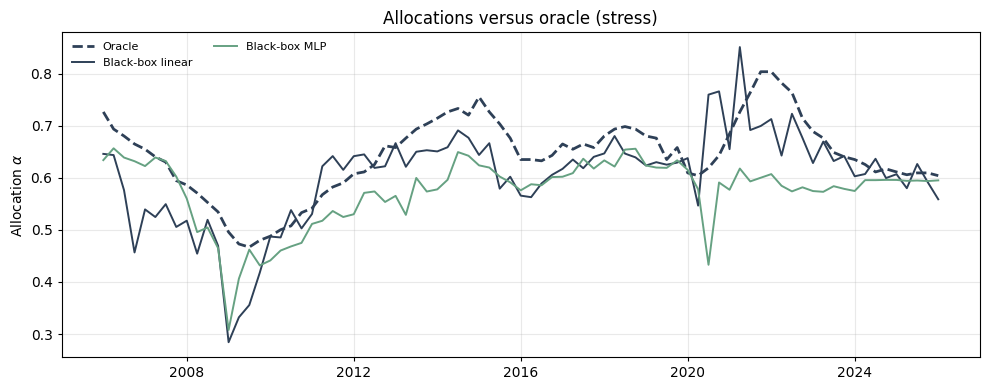

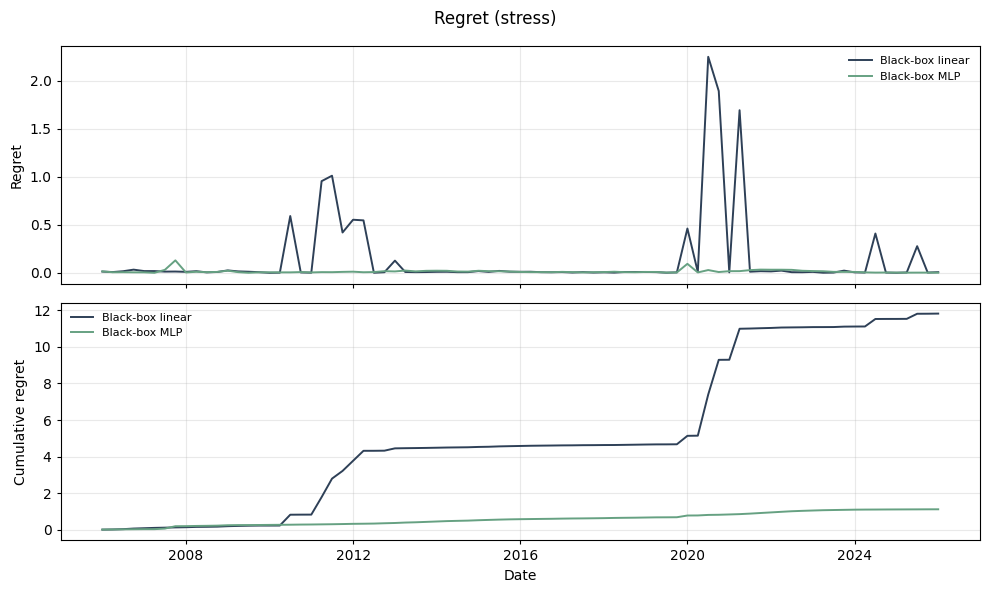

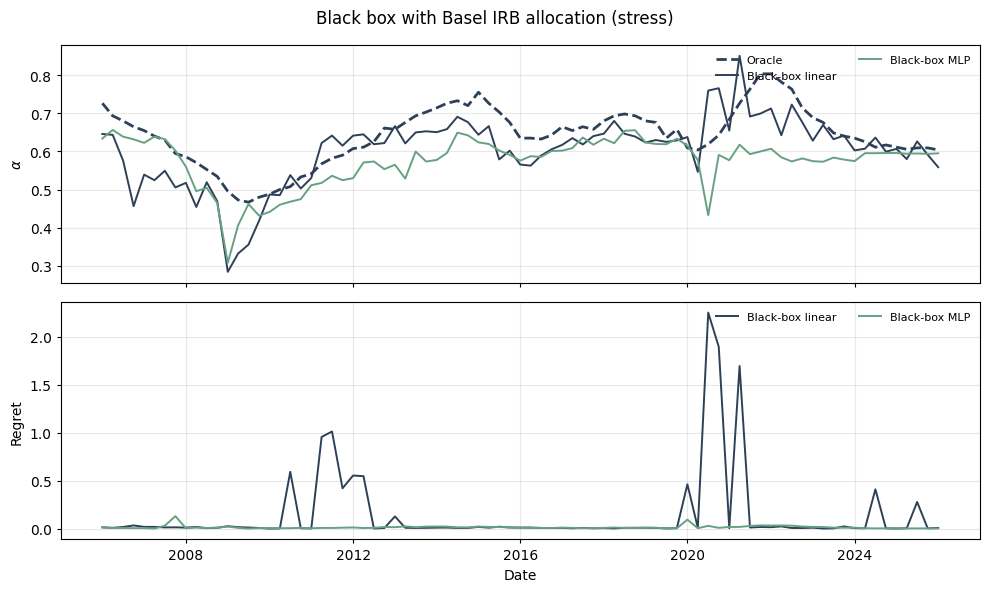

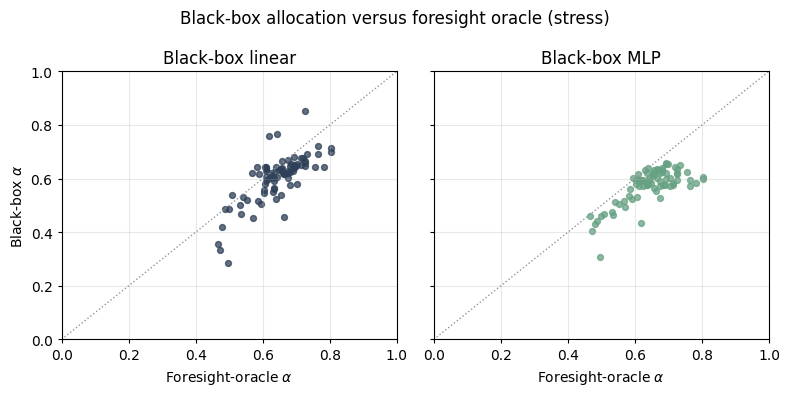

In [12]:
plt.rcdefaults()
plt.rcParams.update({"font.size": 10, "axes.linewidth": 0.8, "xtick.direction": "out", "ytick.direction": "out",
                     "xtick.major.size": 3, "ytick.major.size": 3, "font.sans-serif": ["DejaVu Sans"]})
from minou_colors import MINOU_COLORS
MODEL_COLORS = {"blackbox_linear": MINOU_COLORS["navy"], "blackbox_mlp": MINOU_COLORS["sage"]}
MODEL_LW = {"blackbox_linear": 1.4, "blackbox_mlp": 1.4}
MODEL_LABELS = {"blackbox_linear": "Black-box linear", "blackbox_mlp": "Black-box MLP"}
ORACLE_COLOR = MINOU_COLORS["navy"]
REAL_COLOR = MINOU_COLORS["grey"]

PLOT_MODELS = ["blackbox_linear", "blackbox_mlp"]

def format_date_axis(ax, year_step=2):
    ax.xaxis.set_major_locator(mdates.YearLocator(year_step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.28)


def _model_lines(ax, plot_df, col_prefix, suffix="", models=None):
    for m in (PLOT_MODELS if models is None else models):
        ax.plot(plot_df["date"], plot_df[f"{col_prefix}_{m}"], color=MODEL_COLORS[m],
                lw=MODEL_LW[m], label=f"{MODEL_LABELS[m]}{suffix}")


def plot_split(res, split_name):
    fig_dir = FIGURES_DIR / split_name
    fig_dir.mkdir(parents=True, exist_ok=True)
    plot_df = res.sort_values("date").copy()
    year_step = 2 if len(plot_df) <= 60 else 4

    # 1. Allocation comparison
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Oracle")
    _model_lines(ax, plot_df, "alpha_hat")
    ax.set_ylabel(r"Allocation $\alpha$"); ax.set_title(f"Allocations versus oracle ({split_name})")
    format_date_axis(ax, year_step); ax.legend(frameon=False, fontsize=8, ncol=2); plt.tight_layout()
    plt.savefig(fig_dir / "allocation_comparison.png", dpi=200, bbox_inches="tight"); plt.show()

    # 2. Regret and cumulative regret
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    for m in PLOT_MODELS:
        axes[0].plot(plot_df["date"], plot_df[f"regret_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
        axes[1].plot(plot_df["date"], plot_df[f"regret_{m}"].cumsum(), color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
    axes[0].set_ylabel("Regret"); axes[0].legend(frameon=False, fontsize=8)
    axes[1].set_ylabel("Cumulative regret"); axes[1].set_xlabel("Date"); axes[1].legend(frameon=False, fontsize=8)
    for ax in axes:
        format_date_axis(ax, year_step)
    fig.suptitle(f"Regret ({split_name})"); plt.tight_layout()
    plt.savefig(fig_dir / "regret.png", dpi=200, bbox_inches="tight"); plt.show()

    # 3. Compact panel: allocation + regret
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    fig.subplots_adjust(hspace=0.08)
    axes[0].plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Oracle")
    _model_lines(axes[0], plot_df, "alpha_hat")
    axes[0].set_ylabel(r"$\alpha$")
    for m in PLOT_MODELS:
        axes[1].plot(plot_df["date"], plot_df[f"regret_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
    axes[1].set_ylabel("Regret"); axes[1].set_xlabel("Date")
    for ax in axes:
        format_date_axis(ax, year_step); ax.legend(fontsize=8, frameon=False, loc="upper right", ncol=2)
    fig.suptitle(f"Black box with Basel IRB allocation ({split_name})", fontsize=12)
    plt.tight_layout(); plt.savefig(fig_dir / "blackbox_pd_irb_compact_panel.png", dpi=220, bbox_inches="tight"); plt.show()

    # 4. Black-box alpha vs oracle alpha scatter
    fig, axes = plt.subplots(1, len(PLOT_MODELS), figsize=(4 * len(PLOT_MODELS), 4), sharex=True, sharey=True)
    for ax, m in zip(np.atleast_1d(axes), PLOT_MODELS):
        ax.scatter(plot_df["alpha_oracle"], plot_df[f"alpha_hat_{m}"], s=18, color=MODEL_COLORS[m], alpha=0.75)
        ax.plot([0, 1], [0, 1], color=MINOU_COLORS["grey"], lw=1, ls=":")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_title(MODEL_LABELS[m]); ax.set_xlabel(r"Foresight-oracle $\alpha$")
        ax.grid(True, alpha=0.28)
    np.atleast_1d(axes)[0].set_ylabel(r"Black-box $\alpha$")
    fig.suptitle(f"Black-box allocation versus foresight oracle ({split_name})")
    plt.tight_layout(); plt.savefig(fig_dir / "bb_alpha_vs_oracle_scatter.png", dpi=200, bbox_inches="tight"); plt.show()


for split_name, res in results_by_split.items():
    plot_split(res, split_name)

## Learning curves

Averaged across expanding windows within each split (validation regret only - there is
no PD intermediate to track RMSE for).
Early-stopped windows are padded by carrying the last value forward so the per-epoch
mean has constant composition despite early stopping at different epochs across windows.

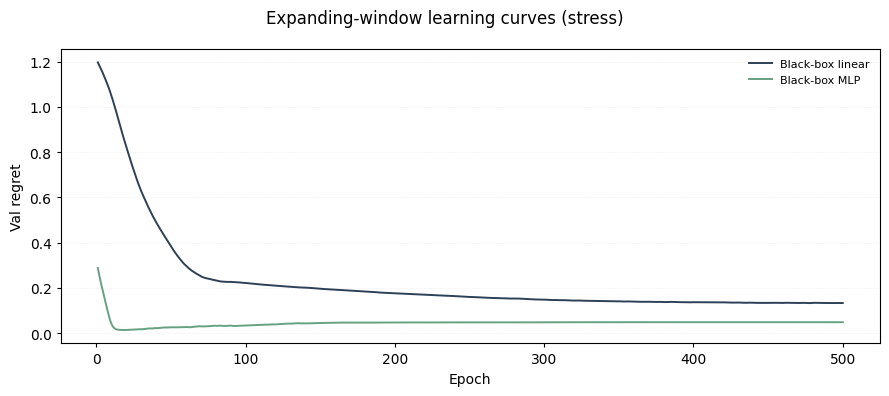

In [13]:
if not training_history.empty:
    for split_name, split_hist in training_history.groupby("split"):
        # Pad each refit's history to the model's max epoch (last value carried forward)
        # so the per-epoch mean has constant composition despite early stopping.
        padded = []
        for model_name, mg in split_hist.groupby("model"):
            max_epoch = int(mg["epoch"].max())
            for _, g in mg.groupby("test_date"):
                gg = (g.sort_values("epoch").set_index("epoch")[["val_loss"]]
                       .reindex(range(1, max_epoch + 1)).ffill().reset_index())
                gg["model"] = model_name
                padded.append(gg)
        mean_history = (pd.concat(padded, ignore_index=True)
                        .groupby(["model", "epoch"], as_index=False)
                        .agg(mean_val_loss=("val_loss", "mean")))

        fig, ax = plt.subplots(figsize=(9, 4))
        for model_name, group in mean_history.groupby("model"):
            group = group.sort_values("epoch"); color = MODEL_COLORS.get(model_name, "grey")
            label = MODEL_LABELS.get(model_name, model_name)
            ax.plot(group["epoch"], group["mean_val_loss"], color=color, lw=1.4, label=label)
        ax.set_ylabel("Val regret"); ax.set_xlabel("Epoch")
        ax.grid(True, axis="y", lw=0.5, alpha=0.3, linestyle=":"); ax.legend(fontsize=8, frameon=False, loc="upper right")
        fig.suptitle(f"Expanding-window learning curves ({split_name})"); plt.tight_layout()
        fig_dir = FIGURES_DIR / split_name
        fig_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(fig_dir / "learning_curves.png", dpi=200, bbox_inches="tight"); plt.show()